In [1]:
# Jupyter cell: make & save a vertical water-depth colorbar PNG
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display, Image as IPyImage


def save_water_depth_colorbar_png(
    out_path="water_depth_cbar_vertical.png",
    *,
    edges=(0.05, 0.10, 0.30, 0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50),
    colors=(
        "#f7fcf0",  # 0.05–0.10
        "#ccebc5",  # 0.10–0.30
        "#a8ddb5",  # 0.30–0.50
        "#7bccc4",  # 0.50–1.00
        "#4eb3d3",  # 1.00–1.50
        "#2b8cbe",  # 1.50–2.00
        "#08589e",  # 2.00–2.50
        "#08306b",  # 2.50–3.00
        "#54278f",  # 3.00–3.50
    ),
    overflow_color="#4d004b",   # ≥ 3.5 m
    label="Water depth (m)",
    fig_height=5.5,
    fig_width=1.6,
    dpi=400
):
    """
    Creates a vertical discrete colorbar matching the LISFLOOD
    water-depth plots (including violet overflow) and saves it as PNG.
    """
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    # --- build cmap & norm ---
    colors_ext = list(colors) + [overflow_color]
    cmap_disc = ListedColormap(colors_ext)
    cmap_disc.set_under((0, 0, 0, 0))  # transparent for < first edge
    norm = BoundaryNorm(edges, cmap_disc.N, extend="max")

    # --- figure ---
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax = fig.add_axes([0.35, 0.05, 0.25, 0.90])  # [left, bottom, width, height]

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
    sm.set_array([])

    cbar = plt.colorbar(
        sm,
        cax=ax,
        orientation="vertical",
        extend="max",
        ticks=list(edges),
    )

    cbar.set_label(label, rotation=90, labelpad=12, fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    # clean look
    for spine in ("top", "right", "left", "bottom"):
        cbar.ax.spines[spine].set_visible(False)

    fig.patch.set_alpha(0.0)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)
    plt.close(fig)

    print(f"✅ Saved colorbar to: {out_path}")
    display(IPyImage(filename=out_path))


✅ Saved colorbar to: /storage/homefs/ge24z347/Liestal_event/water_depth_cbar_vertical.png


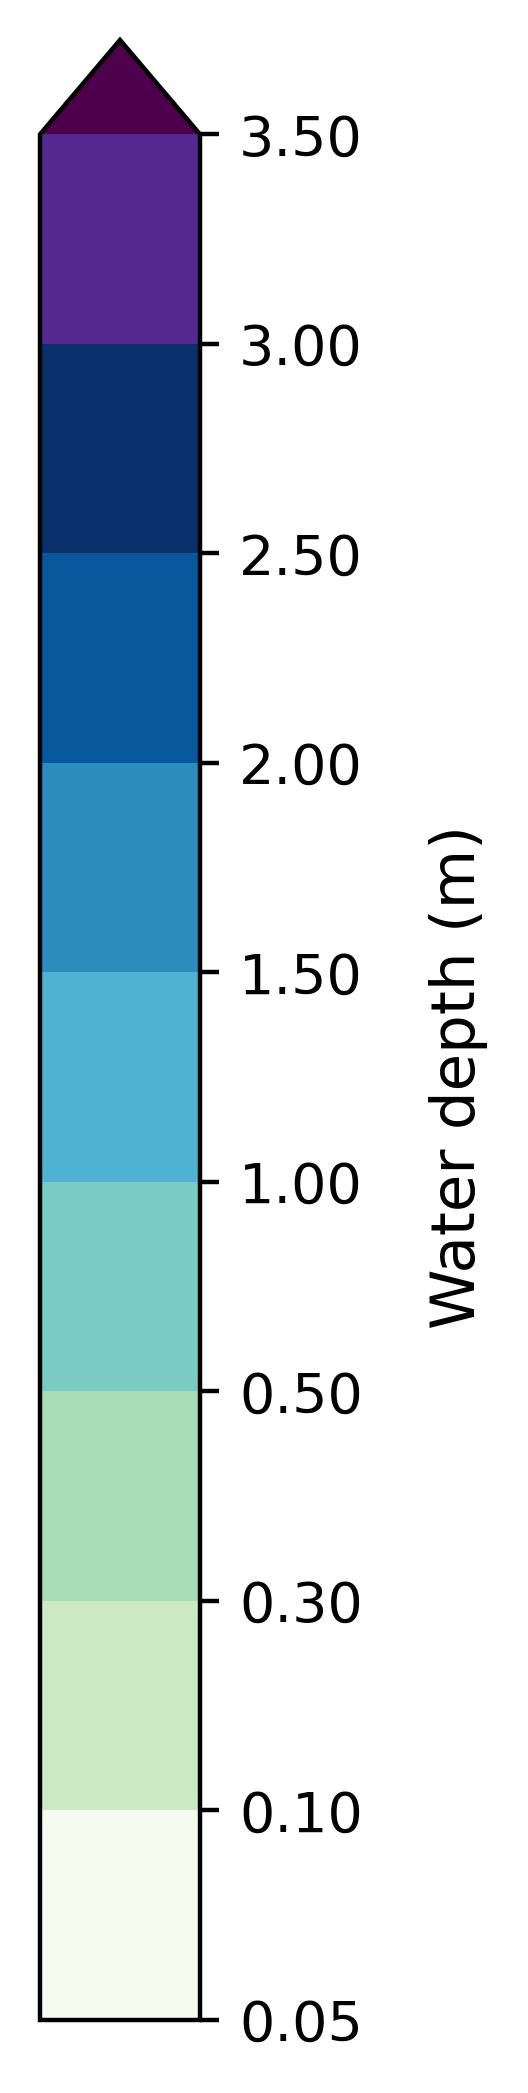

In [2]:
save_water_depth_colorbar_png(
    out_path="/storage/homefs/ge24z347/Liestal_event/water_depth_cbar_vertical.png",
    label="Water depth (m)"
)

In [ ]:
#####

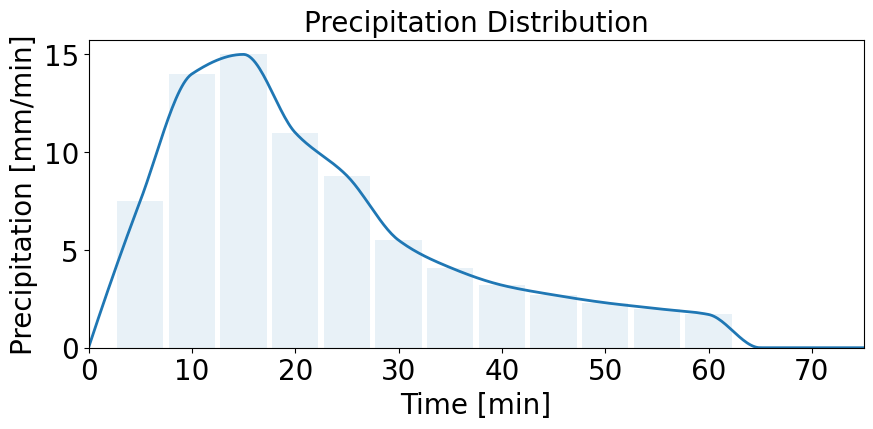

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

time = np.arange(0, 80, 5)
precip = np.array([0, 7.5, 14, 15, 11, 8.8, 5.5, 4.1, 3.2, 2.7, 2.3, 2.0, 1.7, 0, 0, 0])

x_smooth = np.linspace(time.min(), time.max(), 400)
pchip = PchipInterpolator(time, precip)
y_smooth = pchip(x_smooth)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(time, precip, width=4.5, align="center", alpha=0.1)
ax.plot(x_smooth, y_smooth, linewidth=2)

# Labels with fontsize
label_fs = 20
ax.set_xlabel("Time [min]", fontsize=label_fs)
ax.set_ylabel("Precipitation [mm/min]", fontsize=label_fs)
ax.set_title("Precipitation Distribution", fontsize=label_fs)

# Tick labels same size as axis labels
ax.tick_params(axis="both", labelsize=label_fs)

ax.set_xlim(0, 75)

ax.grid(False)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.show()


In [ ]:
### Figure one plotting 

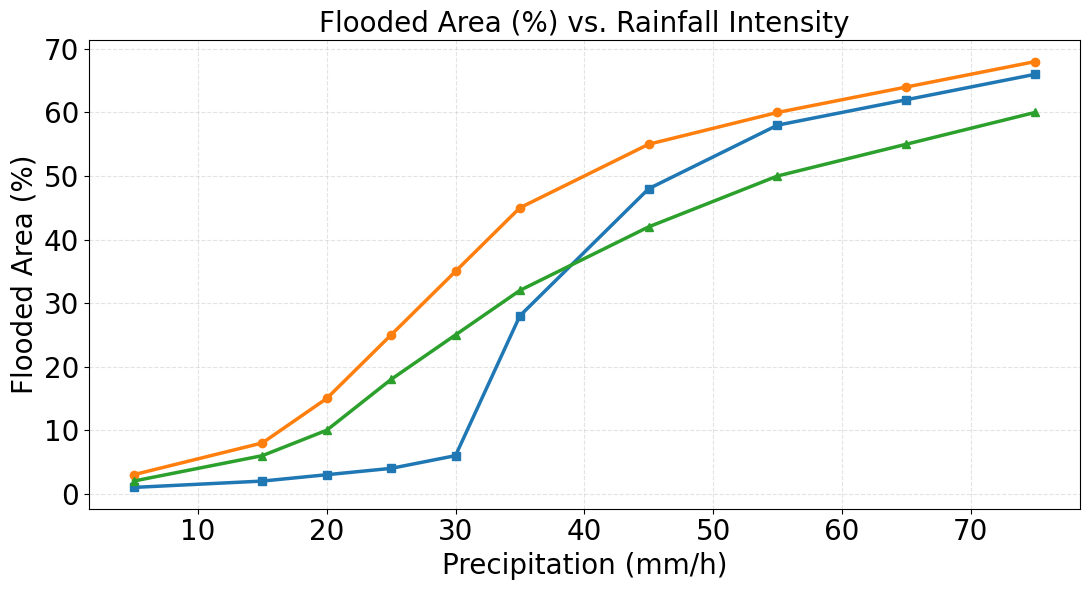

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Precipitation scenarios (mm/h)
x = np.array([5, 15, 20, 25, 30, 35, 45, 55, 65, 75])

# 1) Threshold behaviour: flat until ~30 mm/h, then sharp increase
threshold = np.array([1, 2, 3, 4, 6, 28, 48, 58, 62, 66])

# 2) Early response: starts increasing already around 20 mm/h
early = np.array([3, 8, 15, 25, 35, 45, 55, 60, 64, 68])

# 3) Gradual increase: smooth, concave behaviour
gradual = np.array([2, 6, 10, 18, 25, 32, 42, 50, 55, 60])

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(x, threshold, marker="s", linewidth=2.5, label="Morges")
ax.plot(x, early, marker="o", linewidth=2.5, label="Gordevio")
ax.plot(x, gradual, marker="^", linewidth=2.5, label="Sempach")

# Labels and title
ax.set_title("Flooded Area (%) vs. Rainfall Intensity", fontsize=20)
ax.set_xlabel("Precipitation (mm/h)", fontsize=20)
ax.set_ylabel("Flooded Area (%)", fontsize=20)

ax.tick_params(axis="both", labelsize=20)

# Light grid
ax.grid(True, linestyle="--", alpha=0.35)

# Legend
#ax.legend(loc="lower right", fontsize=12)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()


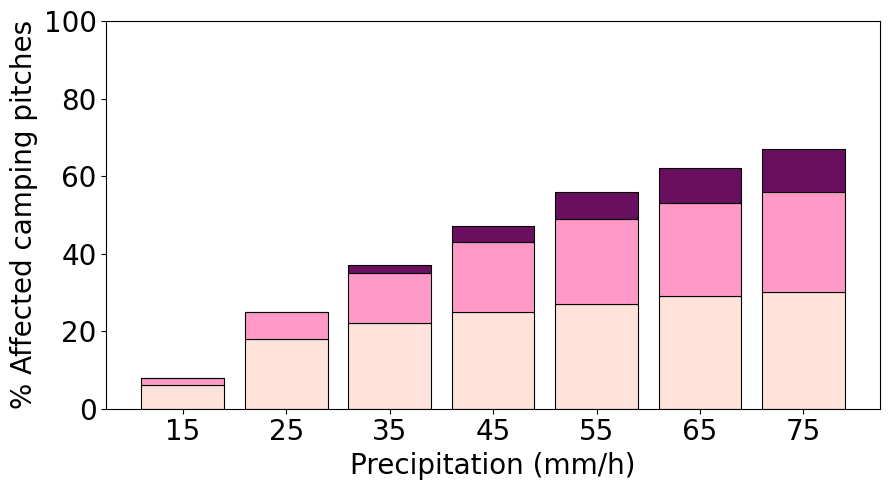

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([15, 25, 35, 45, 55, 65, 75])

depth_010_030 = np.array([6, 18, 22, 25, 27, 29, 30])
depth_gt_030  = np.array([2, 7, 13, 18, 22, 24, 26])
depth_gt_100  = np.array([0, 0, 2, 4, 7, 9, 11])

fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_alpha(0)
ax.set_facecolor("none")

colors = {
    "0.10–0.30 m (mobile)": "#FFE3DB",
    "> 0.30 m (mobile)":    "#FF9AC8",
    "> 1.00 m (non-mobile)": "#6A0F5F"
}

ax.bar(x, depth_010_030, width=8,
       color=colors["0.10–0.30 m (mobile)"],
       edgecolor="black", linewidth=0.8)

ax.bar(x, depth_gt_030, bottom=depth_010_030, width=8,
       color=colors["> 0.30 m (mobile)"],
       edgecolor="black", linewidth=0.8)

ax.bar(x, depth_gt_100,
       bottom=depth_010_030 + depth_gt_030,
       width=8,
       color=colors["> 1.00 m (non-mobile)"],
       edgecolor="black", linewidth=0.8)

ax.set_ylim(0, 100)
ax.set_xlabel("Precipitation (mm/h)", fontsize=20, color="black")
ax.set_ylabel("% Affected camping pitches", fontsize=20, color="black")

ax.tick_params(axis="both", colors="black", labelsize=20)

# 🔑 FORCE ticks to bar centers
ax.set_xticks(x)
ax.set_xticklabels(x)

for spine in ax.spines.values():
    spine.set_color("black")

ax.grid(False)

plt.tight_layout()
plt.show()
